# Getting Started with Machine Learning

**Machine Learning** is a technique that allows computers to learn from data and make decisions without explicit programming.
* It is used in areas such as: Image Recognition, Speech Processing, Language Translation and Recommender Systems.

**Need for Machine Learning**
1. Solving Complex Problems
2. Handling Large Amounts of Data
3. Automating Tasks
4. Personalizing User Experiences

**Challenges**
* Data Quality and Bias:
* Overfitting and Generalization:
* Privacy:
* Explainability:
* Deployment and Resources:

# Data Preparation for Machine Learning

**STEPS:-**
* Loading Dataset
* Understanding the Dataset Structure
* Data Preprocessing:- (Data Cleansing,
Handling Missing Values,
Removing Duplicate Records)
* Feature Engineering
* Dimensionality Reduction
* Feature Selection
* Encoding Categorical Data


# **ML Types**

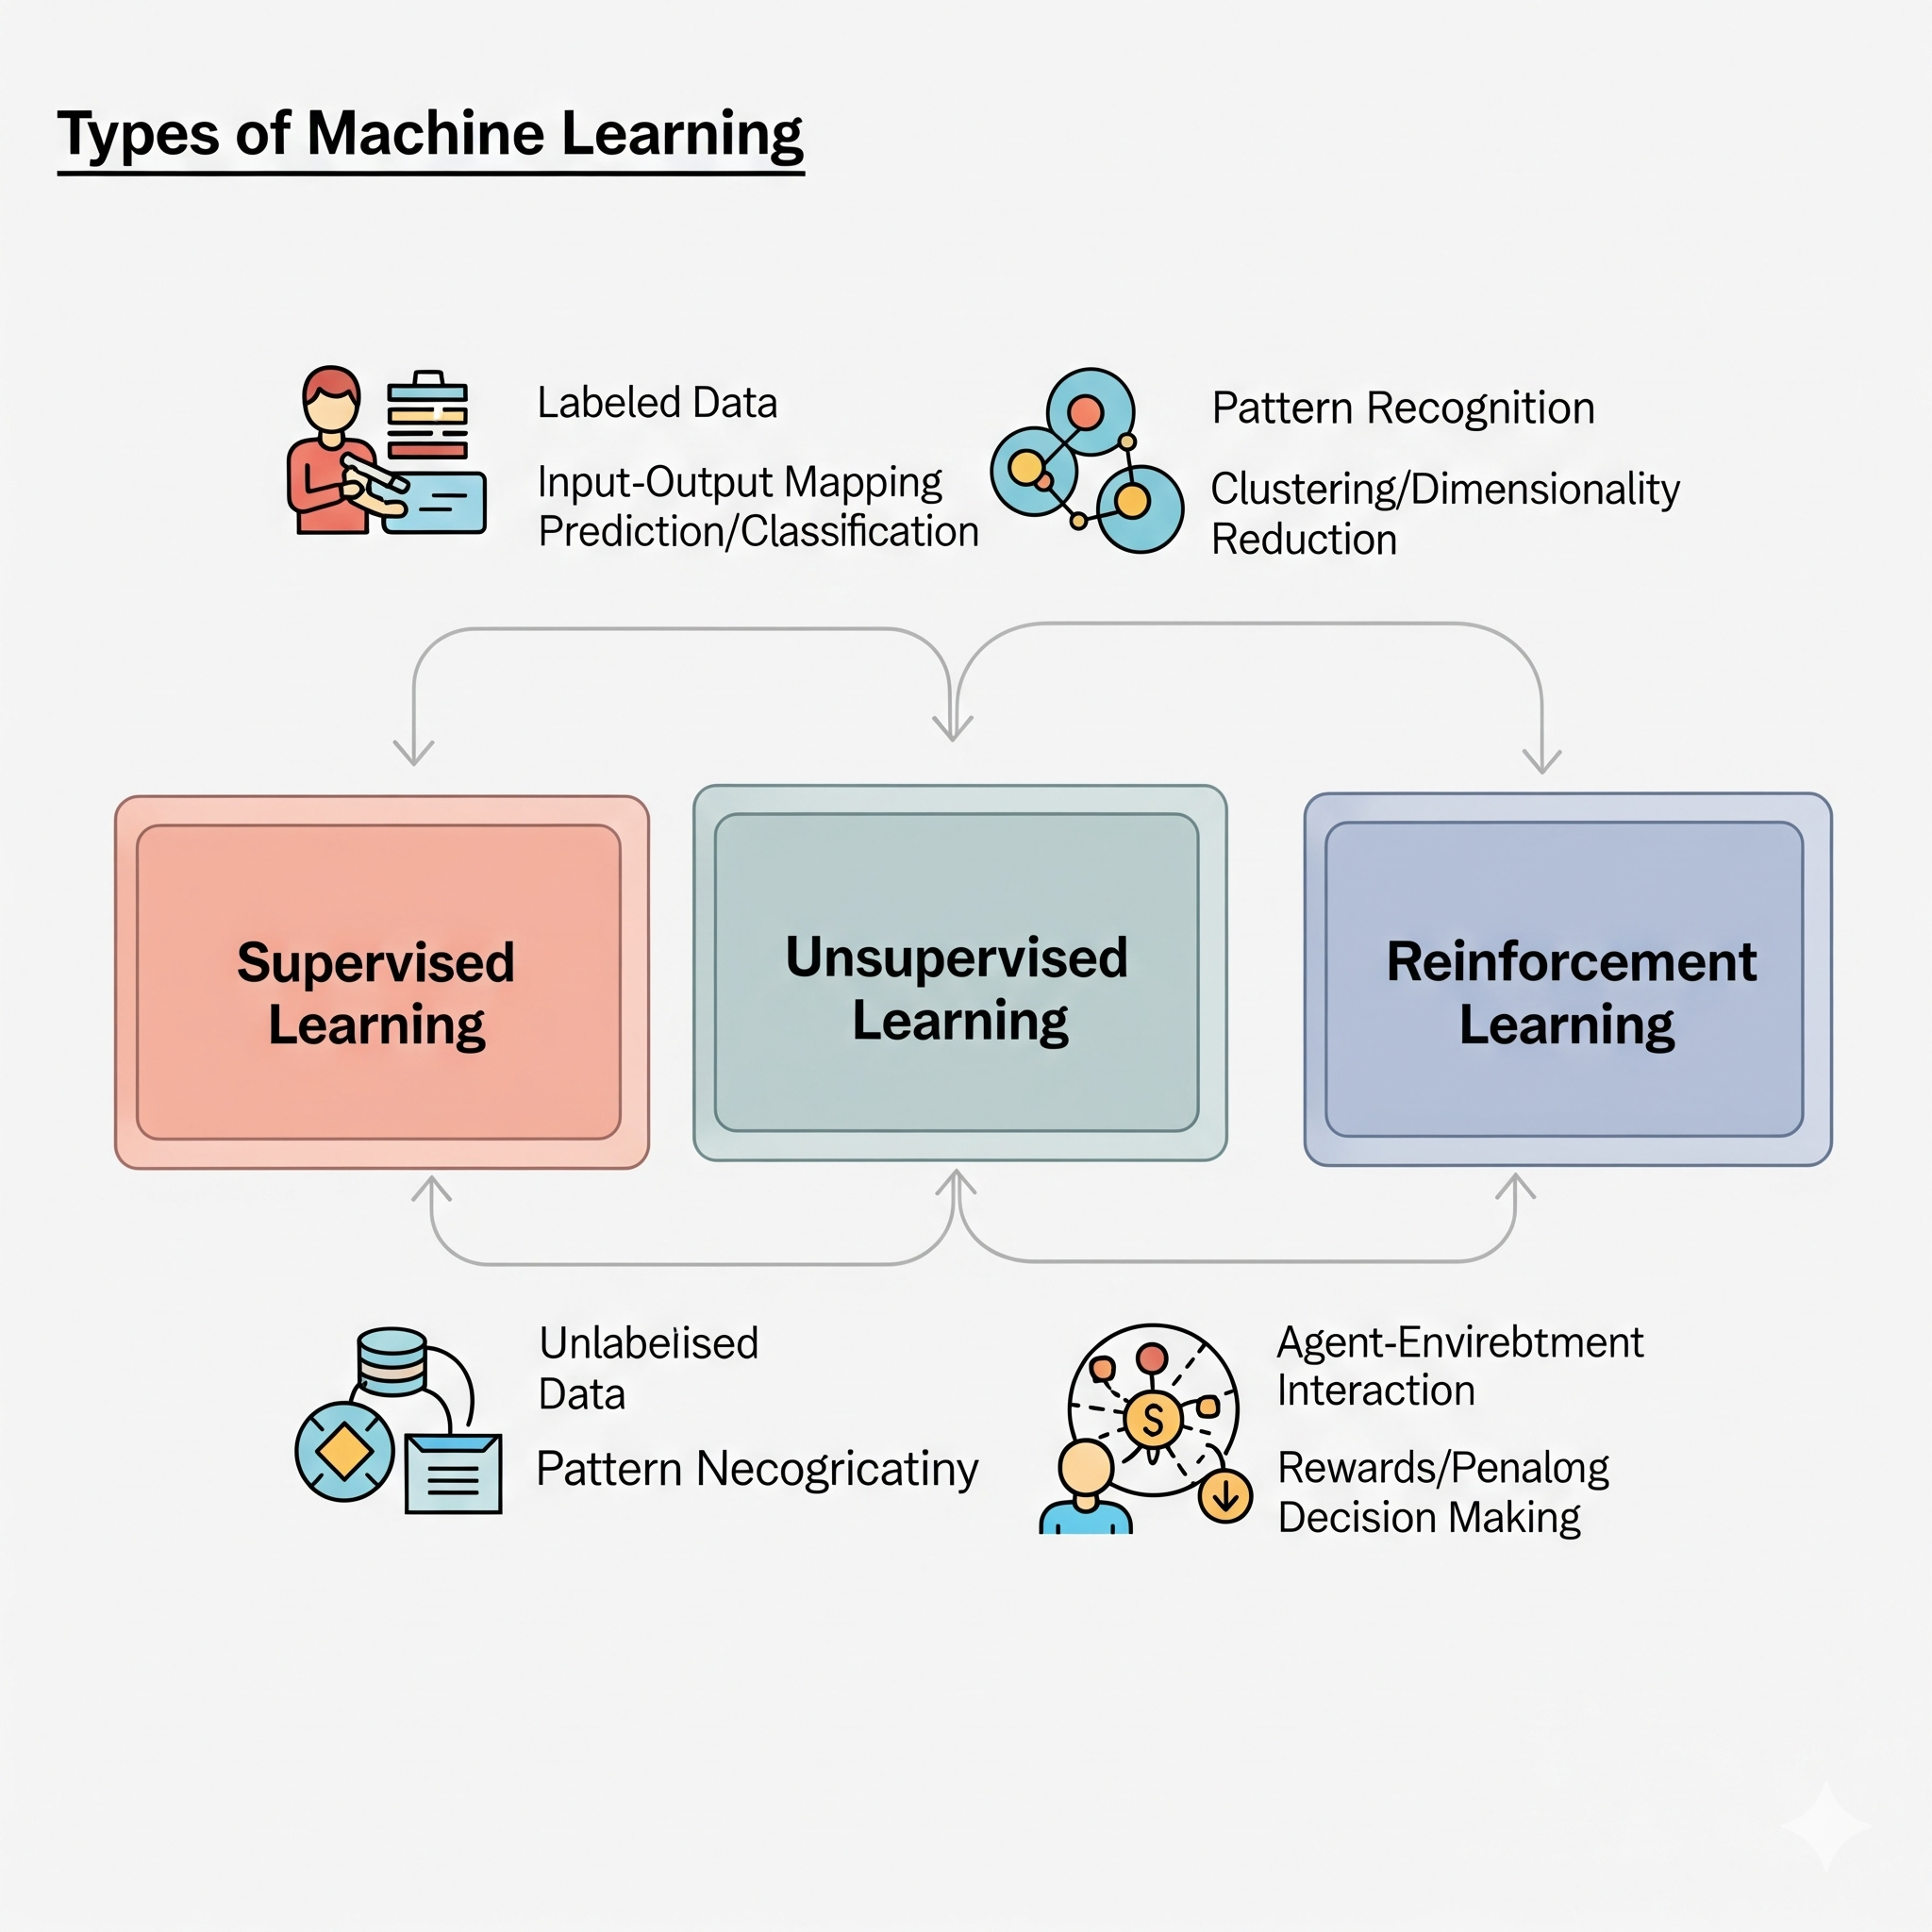

# **Supervised Learning**

Supervised Learning is a type of machine learning where the model is trained on a labeled dataset — meaning that each training example has an input (features) and the correct output (label/target).

👉 The goal is for the model to learn the mapping function from inputs
X to outputs
Y, so it can predict the output for new, unseen inputs.

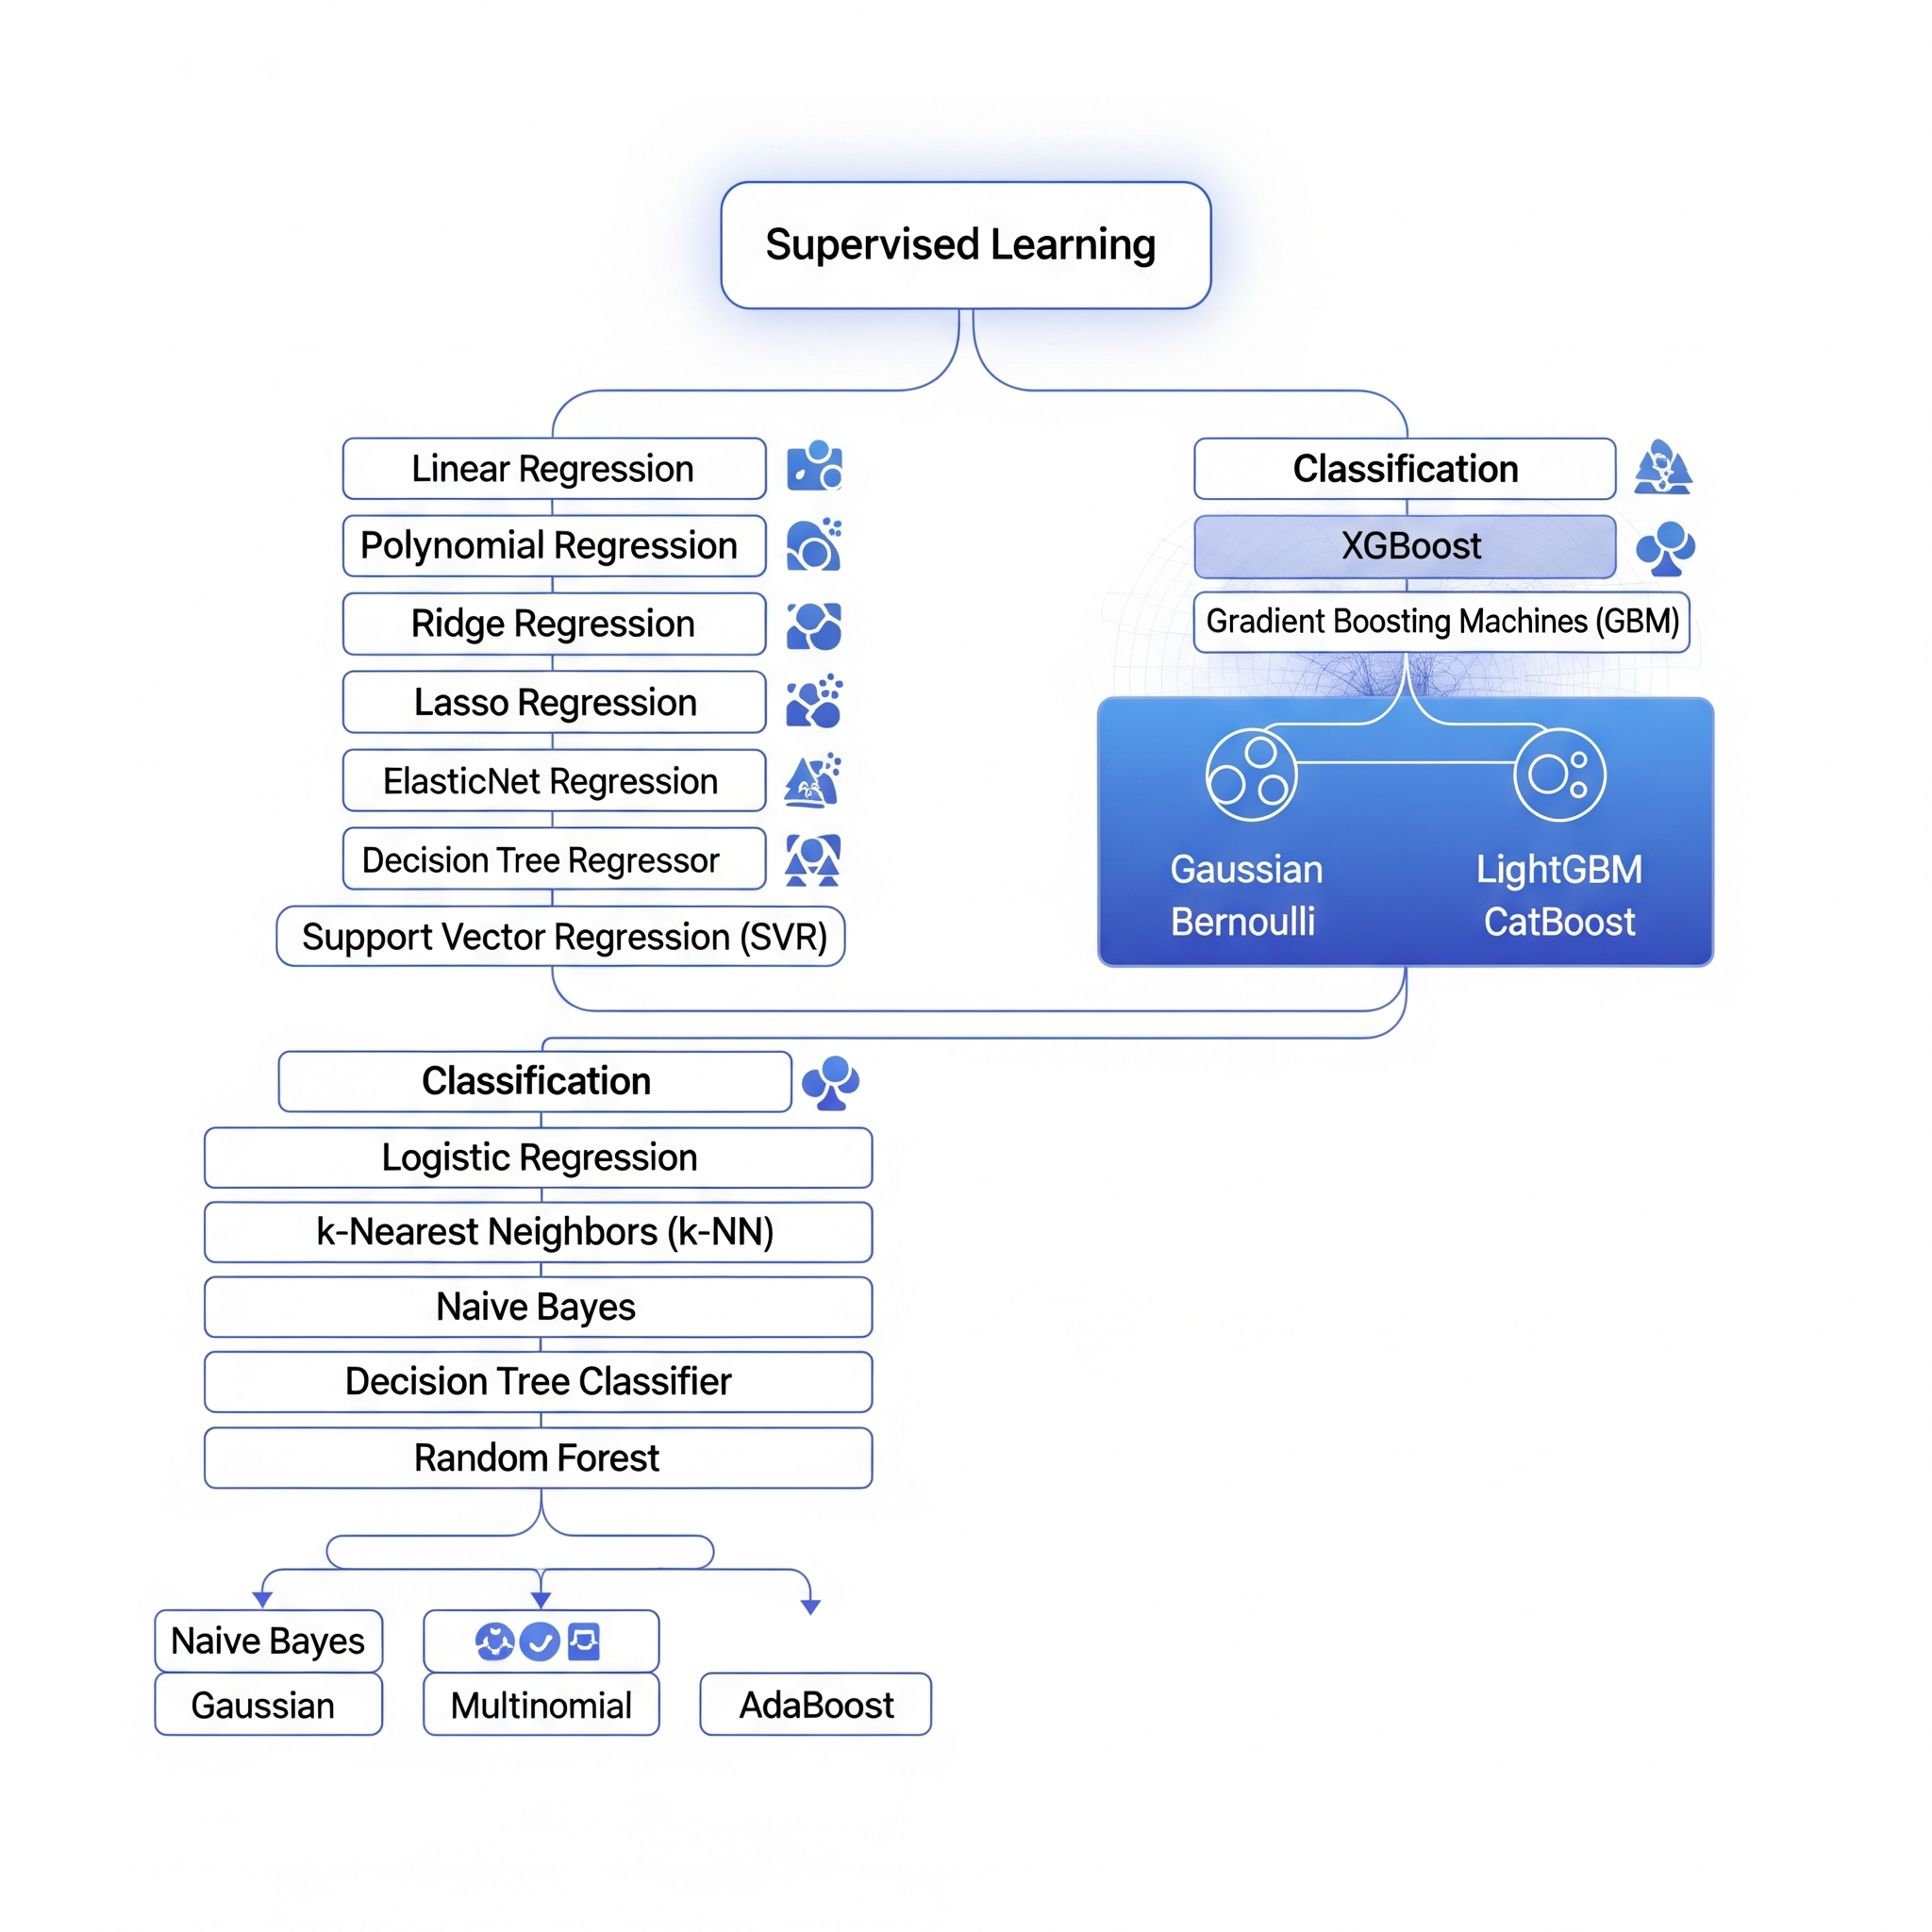

# **Linear Regression**

In [ ]:
# Library import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# Data Load
df = pd.read_csv("data.csv")

In [ ]:
# data show atleast 5 row
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


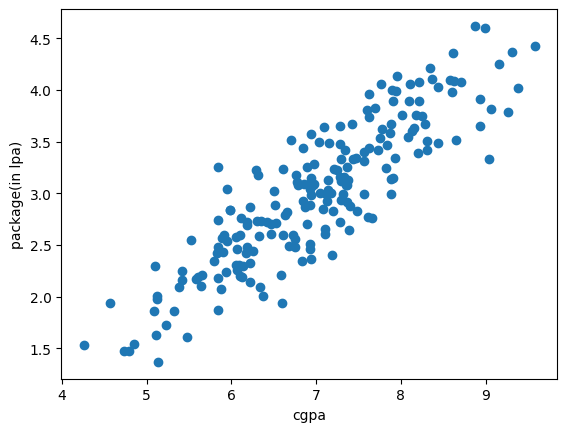

In [ ]:
# Graph plot
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('cgpa')
plt.ylabel('package(in lpa)')
plt.show()

In [ ]:
# Split the data in to X,Y
X= df.iloc[:,0:1]
y = df.iloc[:,-1]

In [ ]:
# import train test split Library
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
# Import Linear Regression Library
from sklearn.linear_model import  LinearRegression
lr = LinearRegression()

In [ ]:
# Fit in to x_train, y_train
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
# predicted value
lr.predict(X_test.iloc[0].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'package(in lpa)')

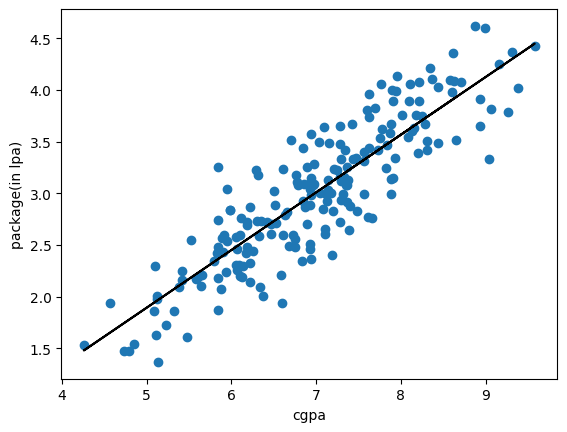

In [ ]:

plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color = 'black')
plt.xlabel('cgpa')
plt.ylabel('package(in lpa)')

### **Linear Regression hyperparameters**

In [ ]:
# Simple Linear Regression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet


lin_reg = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=-1)
lin_reg.fit(X_train, y_train)


y_pred_lin = lin_reg.predict(X_test)
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))

Linear Regression RMSE: 0.34827051717731616


In [ ]:
# Ridge Regression with GridSearchCV
ridge = Ridge()
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(ridge, ridge_params, cv=5, scoring="neg_mean_squared_error")
grid_ridge.fit(X_train, y_train)


print("\nBest Ridge alpha:", grid_ridge.best_params_["alpha"])
y_pred_ridge = grid_ridge.predict(X_test)
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


Best Ridge alpha: 0.01
Ridge RMSE: 0.34827636542449825


In [ ]:
# Lasso Regression with GridSearchCV
lasso = Lasso(max_iter=10000)
lasso_params = {"alpha": [0.01, 0.1, 1, 10]}
grid_lasso = GridSearchCV(lasso, lasso_params, cv=5, scoring="neg_mean_squared_error")
grid_lasso.fit(X_train, y_train)

print("\nBest Lasso alpha:", grid_lasso.best_params_["alpha"])
y_pred_lasso = grid_lasso.predict(X_test)
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))


Best Lasso alpha: 0.01
Lasso RMSE: 0.3500716000332249


In [ ]:
# ElasticNet Regression with GridSearchCV
elastic = ElasticNet(max_iter=10000)
elastic_params = {
    "alpha": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]  # mixing parameter
}
grid_elastic = GridSearchCV(elastic, elastic_params, cv=5, scoring="neg_mean_squared_error")
grid_elastic.fit(X_train, y_train)

print("\nBest ElasticNet params:", grid_elastic.best_params_)
y_pred_elastic = grid_elastic.predict(X_test)
print("ElasticNet RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))


Best ElasticNet params: {'alpha': 0.01, 'l1_ratio': 0.2}
ElasticNet RMSE: 0.34939801420348554


# **Polynomial Regression**

In [ ]:
# Library import
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

In [ ]:
# Load Real Dataset (Diabetes)
data = load_diabetes()
X, y = data.data, data.target

In [ ]:
# For visualization, we’ll use only one feature (BMI - column index 2)
X = X[:, 2].reshape(-1, 1)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Polynomial Regression Pipeline
pipeline = Pipeline([
    ("poly", PolynomialFeatures()),
    ("ridge", Ridge())
])

In [ ]:
# Hyperparameter Grid
param_grid = {
    "poly__degree": [2, 3, 4, 5],          # polynomial degree
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]  # regularization strength
}

In [ ]:
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_squared_error")
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             param_grid={'poly__degree': [2, 3, 4, 5],
                         'ridge__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
# Results
print("Best Parameters:", grid.best_params_)
print("Best CV Score (MSE):", -grid.best_score_)

Best Parameters: {'poly__degree': 2, 'ridge__alpha': 0.01}
Best CV Score (MSE): 3932.340277296948


In [ ]:
# Evaluate on test set
y_pred = grid.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test RMSE: 63.664579944558


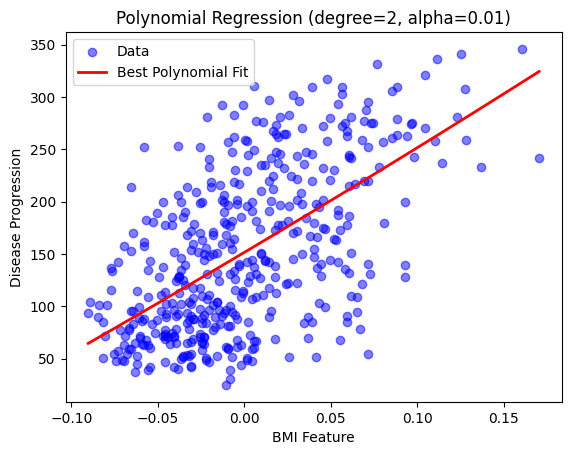

In [ ]:
# Plot Results
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = grid.predict(X_plot)

plt.scatter(X, y, color="blue", alpha=0.5, label="Data")
plt.plot(X_plot, y_plot, color="red", linewidth=2, label="Best Polynomial Fit")
plt.legend()
plt.title(f"Polynomial Regression (degree={grid.best_params_['poly__degree']}, alpha={grid.best_params_['ridge__alpha']})")
plt.xlabel("BMI Feature")
plt.ylabel("Disease Progression")
plt.show()

# **Ridge,Lasso and ElasticNet Regression**



In [ ]:
# Library import
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

In [ ]:
# Load Dataset
data = load_diabetes()
X, y = data.data, data.target

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Ridge Regression
ridge = Ridge()
ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}
grid_ridge = GridSearchCV(ridge, ridge_params, cv=5, scoring="neg_mean_squared_error")
grid_ridge.fit(X_train, y_train)

ridge_best = grid_ridge.best_estimator_
y_pred_ridge = ridge_best.predict(X_test)
print("Best Ridge alpha:", grid_ridge.best_params_["alpha"])
print("Ridge Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Best Ridge alpha: 0.1
Ridge Test RMSE: 53.446111997699646


In [ ]:
# Lasso Regression
lasso = Lasso(max_iter=10000)
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
grid_lasso = GridSearchCV(lasso, lasso_params, cv=5, scoring="neg_mean_squared_error")
grid_lasso.fit(X_train, y_train)

lasso_best = grid_lasso.best_estimator_
y_pred_lasso = lasso_best.predict(X_test)
print("\nBest Lasso alpha:", grid_lasso.best_params_["alpha"])
print("Lasso Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))


Best Lasso alpha: 0.1
Lasso Test RMSE: 52.897953506442185


In [ ]:
# ElasticNet Regression
elastic = ElasticNet(max_iter=10000)
elastic_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.5, 0.8]  # mix between Lasso (L1) and Ridge (L2)
}
grid_elastic = GridSearchCV(elastic, elastic_params, cv=5, scoring="neg_mean_squared_error")
grid_elastic.fit(X_train, y_train)

elastic_best = grid_elastic.best_estimator_
y_pred_elastic = elastic_best.predict(X_test)
print("\nBest ElasticNet params:", grid_elastic.best_params_)
print("ElasticNet Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))


Best ElasticNet params: {'alpha': 0.001, 'l1_ratio': 0.8}
ElasticNet Test RMSE: 53.48287681846635


# **Decision Tree Regressor**

In [ ]:
# Library import
import pandas as pd
from pandas_datareader import data
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score
# from sklearn.datasets import load_boston
from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV

In [ ]:
# Load the Boston dataset from OpenML
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = pd.DataFrame(boston.data)

In [ ]:
df.columns = boston.feature_names
df['MEDV'] = boston.target

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
X = df.iloc[:,0:13]
y = df.iloc[:,13]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [ ]:
rt = DecisionTreeRegressor(criterion = 'friedman_mse', max_depth=5)

In [ ]:
rt.fit(X_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=5)

In [ ]:
y_pred = rt.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.7224163455290411

### **Hyperparameter Tuning**

In [ ]:
param_grid = {
    'max_depth': [2, 4, 8, 10, None],
    'criterion': ['squared_error', 'absolute_error'],  # Corrected 'mae' to 'absolute_error'
    'max_features': [0.25, 0.5, 1.0],
    'min_samples_split': [0.25, 0.5, 1.0]
}

reg = GridSearchCV(DecisionTreeRegressor(), param_grid=param_grid)
reg.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [2, 4, 8, 10, None],
                         'max_features': [0.25, 0.5, 1.0],
                         'min_samples_split': [0.25, 0.5, 1.0]})

In [ ]:
reg.best_score_

np.float64(0.6970704855666008)

In [ ]:
reg.best_params_

{'criterion': 'squared_error',
 'max_depth': 10,
 'max_features': 0.5,
 'min_samples_split': 0.25}

# **Support Vector Regression (SVR)**

In [ ]:
# Library import
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

In [ ]:
# Load Dataset
data = load_diabetes()
X, y = data.data, data.target

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# SVR Model
svr = SVR()

In [ ]:
# Hyperparameter grid
param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
    "epsilon": [0.01, 0.1, 1]
}

In [ ]:
# GridSearchCV
grid = GridSearchCV(svr, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1, 1],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='neg_mean_squared_error')

In [ ]:
best_svr = grid.best_estimator_
best_svr.fit(X_train, y_train)

SVR(C=100, epsilon=0.01, kernel='linear')

In [ ]:
# Predictions
y_pred = best_svr.predict(X_test)
y_pred

array([142.80069048, 162.26711314, 142.99817636, 256.84942624,
       130.34929258, 107.13635023, 221.53156108, 183.10341046,
       100.39460179, 119.99730204, 102.23912385, 145.21866631,
        74.82548526, 197.17261527, 114.12139037, 132.91313989,
       204.86272922, 223.67419902, 176.63750402, 196.9991222 ,
       178.80594312,  97.50873655,  85.50246026, 178.38009538,
       142.38326586, 158.8831469 , 174.39598688, 169.14763927,
        64.71317751, 124.44996299, 163.52185979,  99.98957186,
       132.50761662, 174.16578508, 162.49410043, 176.76685731,
       130.57346306, 130.12027947, 154.87912108,  72.85660966,
        92.59591945, 118.90000396, 152.82653769, 154.59855118,
       164.81505281,  76.53627442,  88.58612277, 106.90275358,
        74.41784263, 143.99817159, 137.73719442,  76.01164743,
       120.77300069, 112.31534987, 168.15934461, 140.84423082,
       105.8856015 , 184.67153656, 113.80732005,  76.27953618,
       171.74304567, 175.19891544, 134.34945181, 120.35

In [ ]:
# Results
print("Best Parameters:", grid.best_params_)
print("Best CV Score (MSE):", -grid.best_score_)

Best Parameters: {'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score (MSE): 3343.171317553217


In [ ]:
# Evaluate on test set
best_svr = grid.best_estimator_
y_pred = best_svr.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test RMSE: 54.611145110205804


# **Random Forest Regression**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [ ]:
# 2. Importing Dataset
df= pd.read_csv('/content/Position_Salaries.csv')
print(df)

# 3. Data Preparation
X = df.iloc[:,1:2].values
y = df.iloc[:,2].values

In [ ]:
# 4. Encoding categorical columns

label_encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

# 5. Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# 6. Random Forest Regressor Model
regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

regressor.fit(X_train, y_train)



In [ ]:
# 7. Making predictions and Evaluating
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

# **Logistic Regression**

In [ ]:
# Library import
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load sample dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Logistic Regression with hyperparameters
log_reg = LogisticRegression(
    penalty='l2',
    C=0.5,
    solver='saga',
    max_iter=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

In [ ]:
# Train the model
log_reg.fit(X_train, y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=500, n_jobs=-1,
                   random_state=42, solver='saga')

In [ ]:
# Predictions
y_pred = log_reg.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9824561403508771

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# **K-Nearest Neighbors (KNN)**

In [ ]:
# Library import
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# KNN with hyperparameters
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    algorithm='auto',
    leaf_size=30,
    p=2,
    n_jobs=-1
)

In [ ]:
# Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=7, weights='distance')

In [ ]:
# Predictions
y_pred = knn.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# **Naive Bayes classification**

In [ ]:
# Library import
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [ ]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Gaussian Naive Bayes
gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

In [ ]:
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("\nGaussianNB Classification Report:\n", classification_report(y_test, y_pred_gnb))

GaussianNB Accuracy: 0.9649122807017544

GaussianNB Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# **Multinomial Naive Bayes**

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load dataset
categories = ['alt.atheism', 'sci.space']
data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))


In [ ]:
# Convert text to word counts
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data.data)
y = data.target

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Hyperparameters
mnb = MultinomialNB(
    alpha=1.0,
    fit_prior=True
)
mnb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Predictions
y_pred = mnb.predict(X_test)

In [ ]:
# Evaluation
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

MultinomialNB Accuracy: 0.9302325581395349

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92        86
           1       0.97      0.91      0.94       129

    accuracy                           0.93       215
   macro avg       0.92      0.94      0.93       215
weighted avg       0.93      0.93      0.93       215



# **Decision Tree Classifier**

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Hyperparameters
dt = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=None,
    random_state=42
)

In [ ]:
# Train model
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=4,
                       random_state=42)

In [ ]:
# Predictions
y_pred = dt.predict(X_test)

In [ ]:
# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.9473684210526315

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# **Random Forest classifier**

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Random Forest Classifier with hyperparameters
rf = RandomForestClassifier(
    n_estimators=200,     # number of trees in the forest
    criterion="gini",     # "gini", "entropy", "log_loss"
    max_depth=6,          # limit depth of each tree
    min_samples_split=4,  # minimum samples to split a node
    min_samples_leaf=2,   # minimum samples in a leaf node
    bootstrap=True,       # use bootstrap samples
    n_jobs=-1,            # use all CPUs
    random_state=42
)

In [ ]:
# Train model
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=2, min_samples_split=4,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# Predictions
y_pred = rf.predict(X_test)

In [ ]:
# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# ***Xgboost***

In [ ]:
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Hyperparameters
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

In [ ]:
# Train the model
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:38:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predictions
y_pred = xgb_model.predict(X_test)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


# **LightGBM**

In [ ]:
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Hyperparameters
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

In [ ]:
# Train model
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(colsample_bytree=0.8, max_depth=4, n_estimators=200,
               random_state=42, reg_alpha=0.1, reg_lambda=1, subsample=0.8)

In [ ]:
# Predictions
y_pred = lgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Accuracy
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred))

LightGBM Accuracy: 0.9736842105263158


# **Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Hyperparameters
gbm_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

In [ ]:
# Train model
gbm_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, min_samples_leaf=2,
                           min_samples_split=3, n_estimators=300,
                           random_state=42, subsample=0.8)

In [ ]:
# Predictions
y_pred = gbm_model.predict(X_test)

In [ ]:
# Accuracy
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred))

Gradient Boosting Accuracy: 0.9649122807017544


# **AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Hyperparameters
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

In [ ]:
# Train model
ada_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.5, n_estimators=200, random_state=42)

In [ ]:
# Predictions
y_pred = ada_model.predict(X_test)

In [ ]:
# Accuracy
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred))

AdaBoost Accuracy: 0.9649122807017544


# **CatBoost**

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Hyperparameters
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    border_count=64,
    bagging_temperature=1,
    random_seed=42,
    verbose=0
)

In [ ]:
# Train model
cat_model.fit(X_train, y_train)

In [ ]:
# Predictions
y_pred = cat_model.predict(X_test)

In [ ]:
# Accuracy
print("CatBoost Accuracy:", accuracy_score(y_test, y_pred))

CatBoost Accuracy: 0.9649122807017544


# **Unsupervised Learning**

Unsupervised Learning is a type of machine learning where the model is trained on unlabeled data — meaning the dataset has only inputs (features) and no outputs/labels.

👉 The goal is for the model to discover hidden patterns, structures, or groupings in the data on its own.

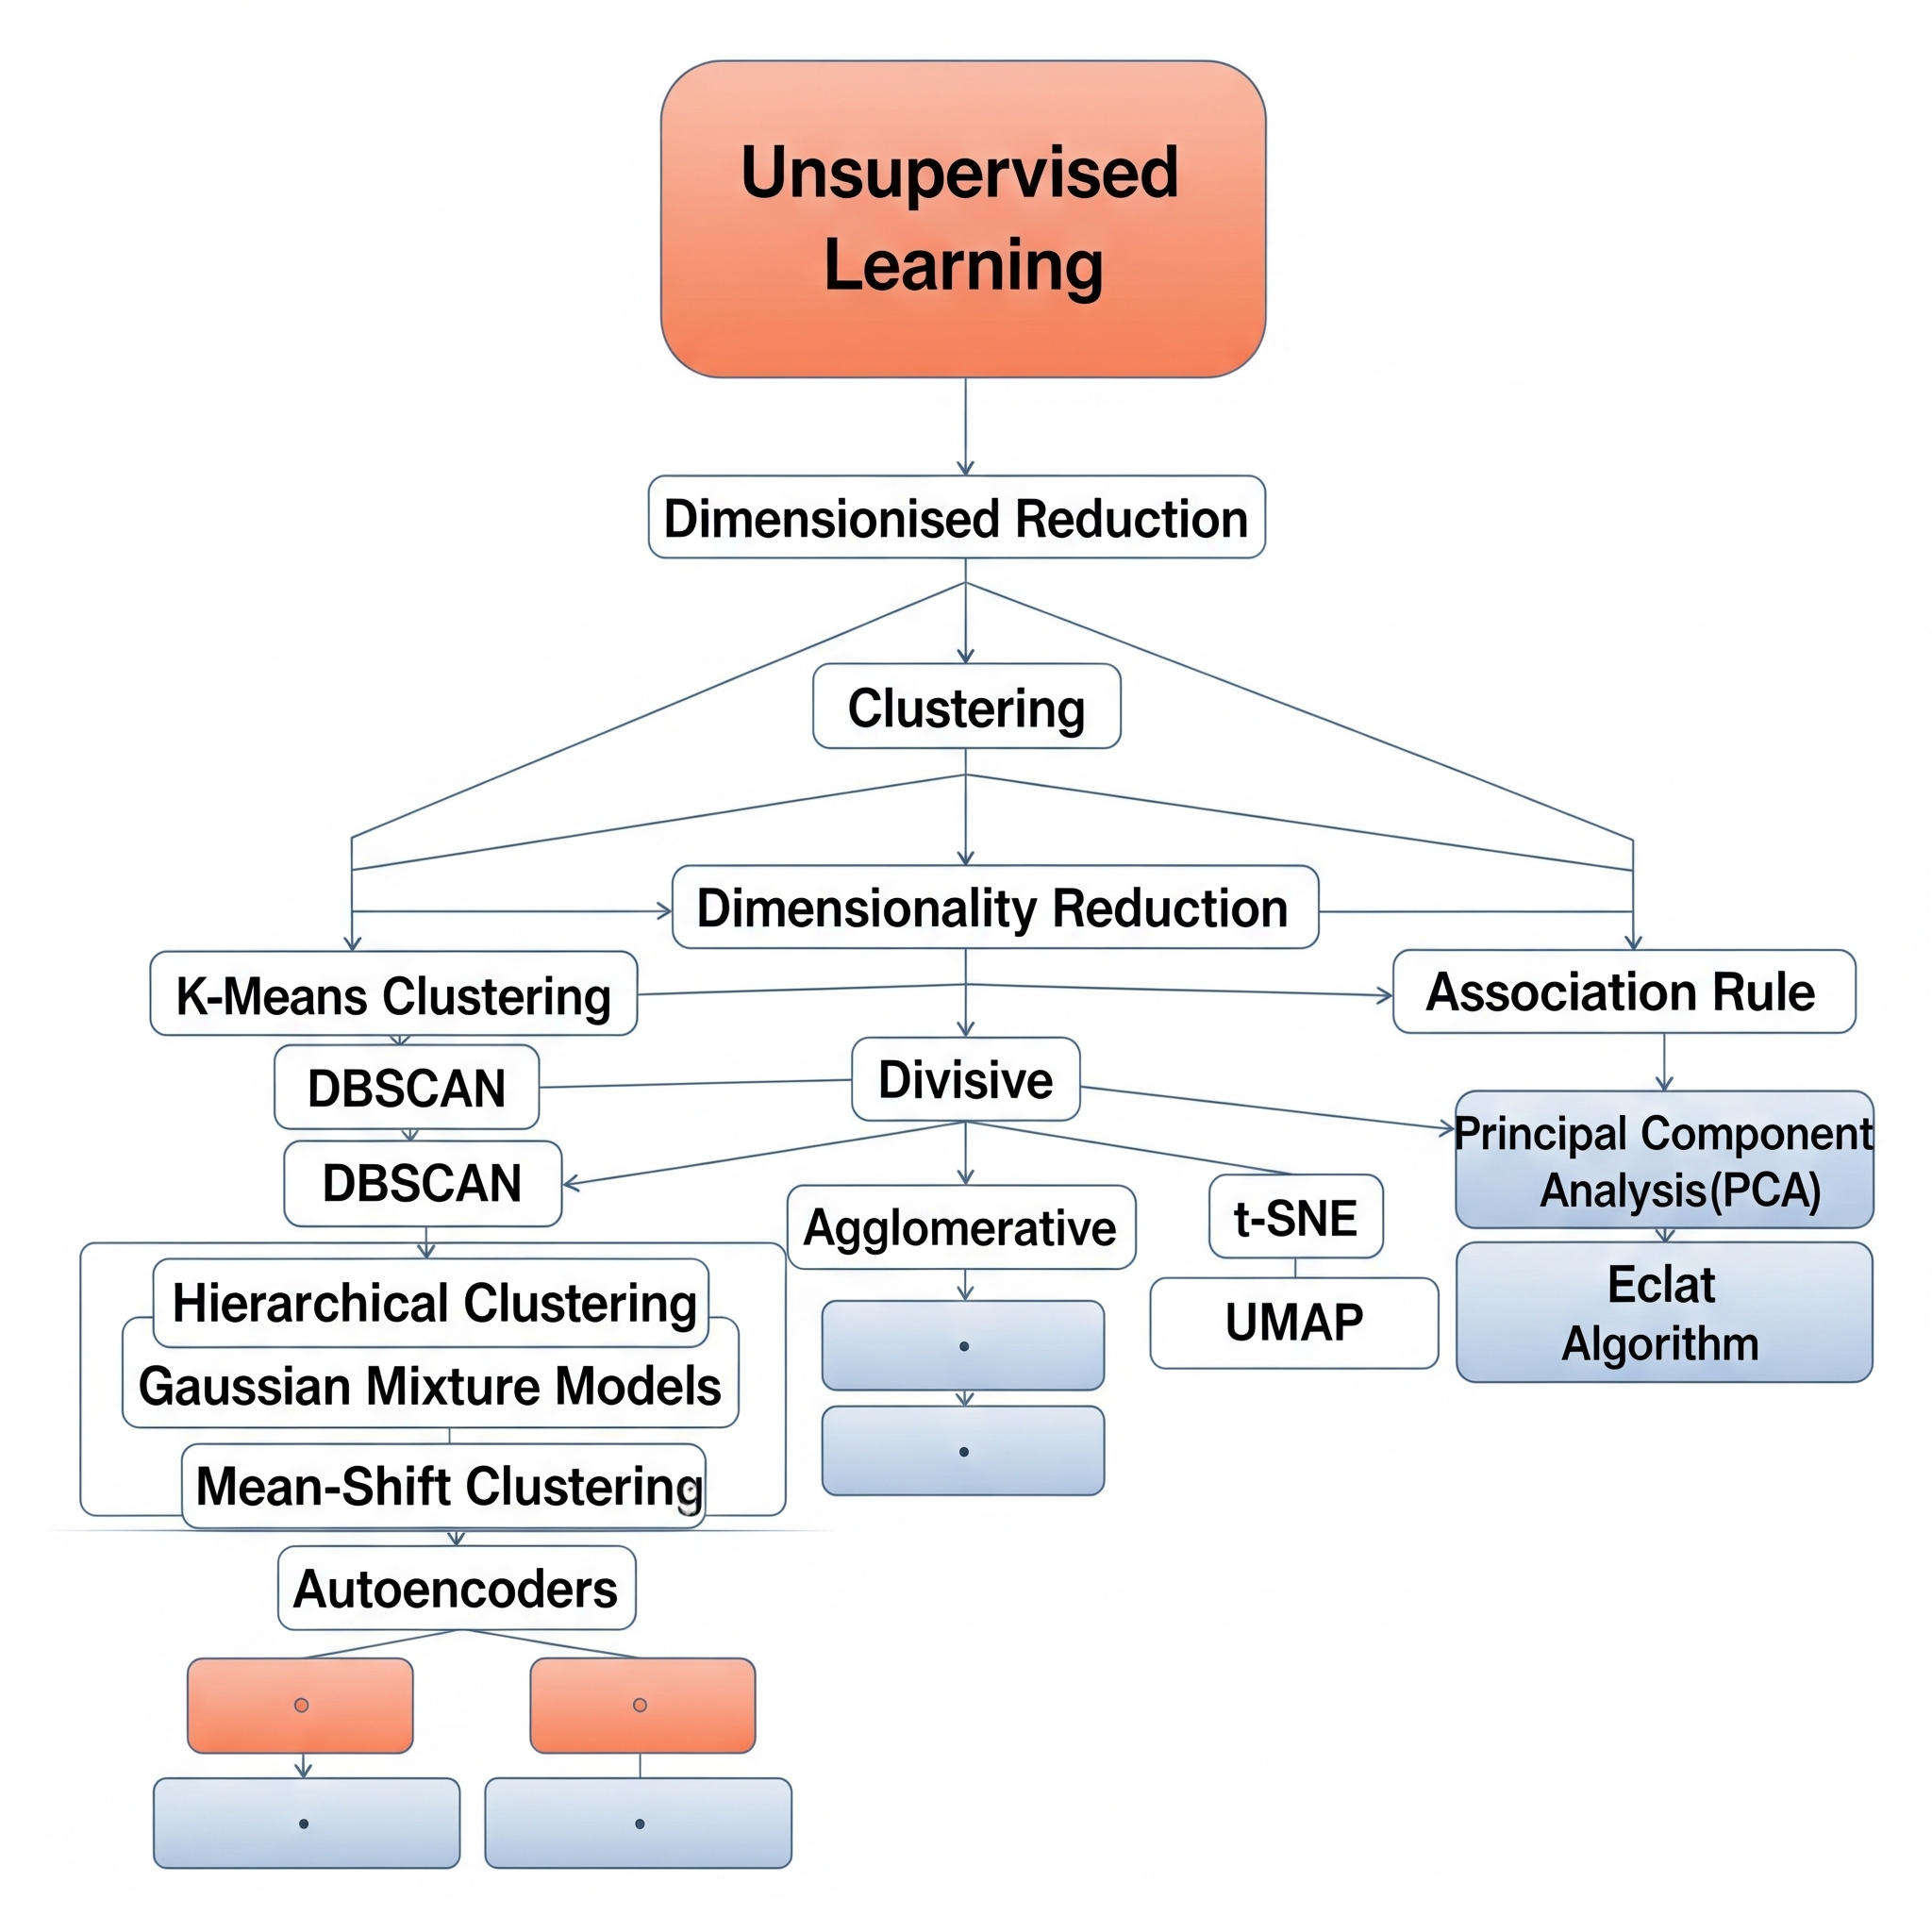

# **K-Means Clustering**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
data = load_iris()
X = data.data

In [ ]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Hyperparameters
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

In [ ]:
# Fit model
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
# Cluster labels
labels = kmeans.labels_

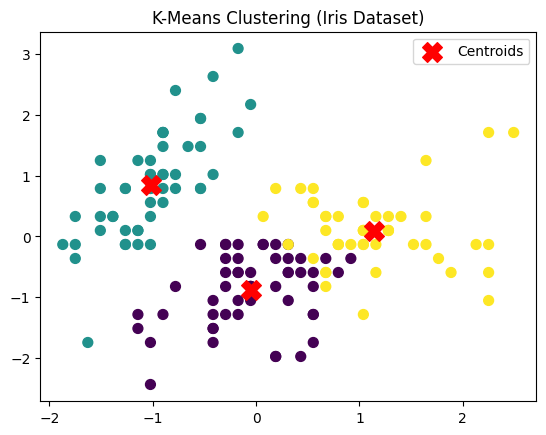

In [ ]:
# Plot results
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering (Iris Dataset)")
plt.legend()
plt.show()

# **Agglomerative Hierarchical Clustering**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch

In [ ]:
# Load dataset (Iris)
data = load_iris()
X = data.data

In [ ]:
# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
agg_model = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

In [ ]:
# Fit model
labels = agg_model.fit_predict(X_scaled)

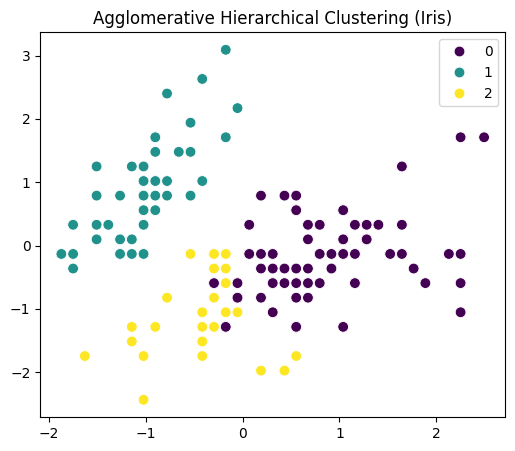

In [ ]:
# Plot clusters
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels, palette='viridis', s=60)
plt.title("Agglomerative Hierarchical Clustering (Iris)")
plt.show()

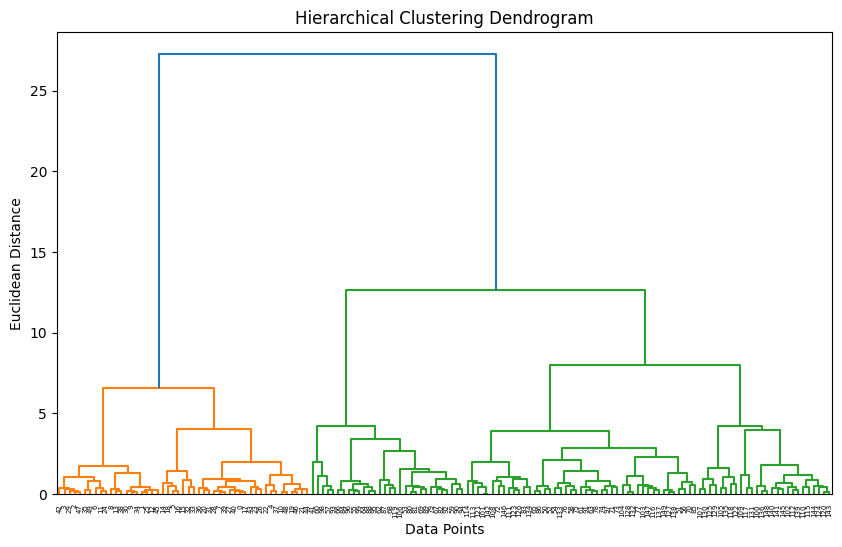

In [ ]:
# Plot Dendrogram
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# **DBSCAN**

In [ ]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [ ]:
# Generate dataset
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

In [ ]:
# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5,
    metric='euclidean'
)

In [ ]:
# Fit model
labels = dbscan.fit_predict(X_scaled)

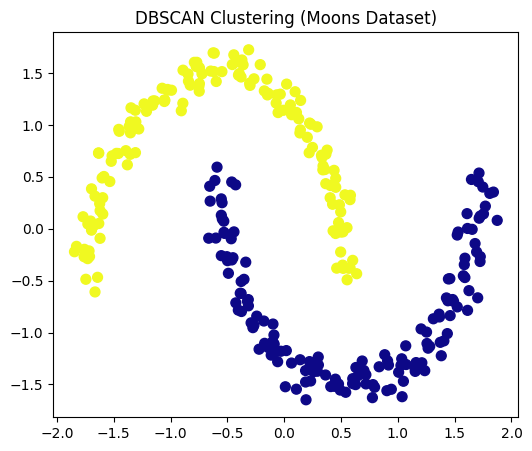

In [ ]:
# Plot results
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='plasma', s=50)
plt.title("DBSCAN Clustering (Moons Dataset)")
plt.show()

# **Gaussian Mixture Model**

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
data = load_iris()
X = data.data

In [ ]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Hyperparameters
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    max_iter=200,
    n_init=5,
    random_state=42
)

In [ ]:
# Fit model
gmm.fit(X_scaled)

GaussianMixture(max_iter=200, n_components=3, n_init=5, random_state=42)

In [ ]:
# Predict clusters
labels = gmm.predict(X_scaled)

In [ ]:
# Probabilities of belonging to each cluster
probs = gmm.predict_proba(X_scaled)

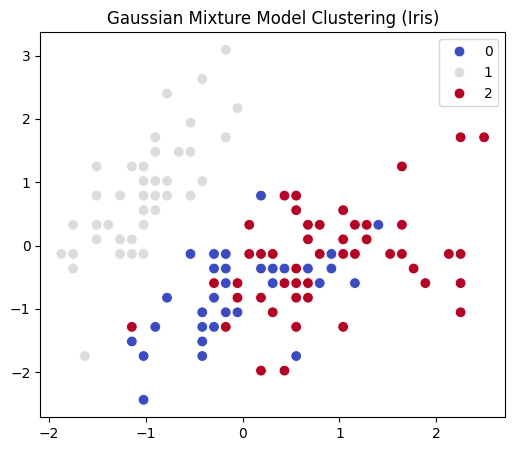

In [ ]:
# Plot clusters
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=labels, palette='coolwarm', s=60)
plt.title("Gaussian Mixture Model Clustering (Iris)")
plt.show()

**We have added some extra content to this notebook.**

# **PCA**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
data = load_iris()
X, y = data.data, data.target

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# pipeline
pipeline = Pipeline([
    ('pca', PCA()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [ ]:
param_grid = {
    'pca__n_components': [2, 3, None],   # PCA hyperparameter
    'clf__C': [0.1, 1, 10],              # Logistic Regression hyperparameter
    'clf__solver': ['lbfgs', 'liblinear']
}

In [ ]:
# GridSearchCV for best hyperparameters
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pca', PCA()),
                                       ('clf',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'clf__C': [0.1, 1, 10],
                         'clf__solver': ['lbfgs', 'liblinear'],
                         'pca__n_components': [2, 3, None]},
             scoring='accuracy')

In [ ]:
# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'clf__C': 1, 'clf__solver': 'lbfgs', 'pca__n_components': 2}
Best Cross-Validation Score: 0.975


In [ ]:
# Test accuracy
y_pred = grid_search.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9


# **LDA**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# Load dataset
data = load_iris()
X, y = data.data, data.target

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# pipeline
lda_pipeline = Pipeline([
    ('lda', LDA()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [ ]:
lda_params = {
    'lda__n_components': [1, 2],          # LDA hyperparameter (max = n_classes-1)
    'clf__C': [0.1, 1, 10],
    'clf__solver': ['lbfgs', 'liblinear']
}


In [ ]:
lda_search = GridSearchCV(lda_pipeline, lda_params, cv=5, scoring='accuracy')
lda_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('lda', LinearDiscriminantAnalysis()),
                                       ('clf',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'clf__C': [0.1, 1, 10],
                         'clf__solver': ['lbfgs', 'liblinear'],
                         'lda__n_components': [1, 2]},
             scoring='accuracy')

In [ ]:
print("LDA Best Parameters:", lda_search.best_params_)
print("LDA Best CV Score:", lda_search.best_score_)
print("LDA Test Accuracy:", accuracy_score(y_test, lda_search.predict(X_test)))

LDA Best Parameters: {'clf__C': 10, 'clf__solver': 'lbfgs', 'lda__n_components': 1}
LDA Best CV Score: 0.9833333333333334
LDA Test Accuracy: 1.0


#**Machine Learning Pipeline**
A Machine Learning Pipeline is a systematic workflow designed to automate the process of building, training, and deploying ML models. It includes several steps, such as:



**Steps to build Machine Learning Pipeline :-**

Step 1: Import Required Libraries


Step 2: Load and Prepare the Data
* Select relevant features
* Display the first few rows of the dataset

Step 3: Define Preprocessing Steps
* Define transformers for preprocessing
* Combine transformers into a single preprocessor

Step 4: Split Data into Training and Testing Sets
* Define target and features
* Split into training and testing sets

Step 5: Build the Machine Learning Pipeline
* Define the pipeline (includes preprocessing + RandomForest classifier)

Step 6: Train the Model

* Train the model using the pipeline

Step 7: Evaluate the Model
* Make predictions on the test data
* Compute accuracy of the model

Step 8: Save and Load the Model
* Save the trained pipeline (preprocessing + model)

**Implementation code:-**

In [ ]:


# Step 1: Import Required Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib  # For saving and loading models

# Step 2: Load and Prepare the Data
# Load dataset (Titanic dataset as an example)
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Select relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']].dropna()  # Drop rows with missing values

# Display the first few rows of the dataset
print("Data Sample:\n", df.head())

# Step 3: Define Preprocessing Steps
# Define numerical and categorical features
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']

# Define transformers for preprocessing
num_transformer = StandardScaler()  # Standardize numerical features
cat_transformer = OneHotEncoder(handle_unknown='ignore')  # One-hot encode categorical features

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Step 4: Split Data into Training and Testing Sets
# Define target and features
X = df[features]
y = df['Survived']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Step 5: Build the Machine Learning Pipeline
# Define the pipeline (includes preprocessing + RandomForest classifier)
pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Apply preprocessing steps
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))  # ML model (RandomForest)
])

# Step 6: Train the Model
# Train the model using the pipeline
pipeline.fit(X_train, y_train)
print("Model training complete!")

# Step 7: Evaluate the Model
# Make predictions on the test data
y_pred = pipeline.predict(X_test)

# Compute accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Step 8: Save and Load the Model
# Save the trained pipeline (preprocessing + model)
joblib.dump(pipeline, 'ml_pipeline.pkl')

# Load the model back
loaded_pipeline = joblib.load('ml_pipeline.pkl')

# Predict using the loaded model
sample_data = pd.DataFrame([{'Pclass': 3, 'Sex': 'male', 'Age': 25, 'SibSp': 0, 'Parch': 0, 'Fare': 7.5, 'Embarked': 'S'}])
prediction = loaded_pipeline.predict(sample_data)

# Output prediction for a sample input
print(f"Prediction for Sample Data: {'Survived' if prediction[0] == 1 else 'Did not Survive'}")

**Benefits of Machine Learning pipeline**

1. Automation and Efficiency:
2. Faster Model Deployment:
3. Improve Accuracy & Consistency:
4. Handles Large Data easily:
5. Cost-Effective:

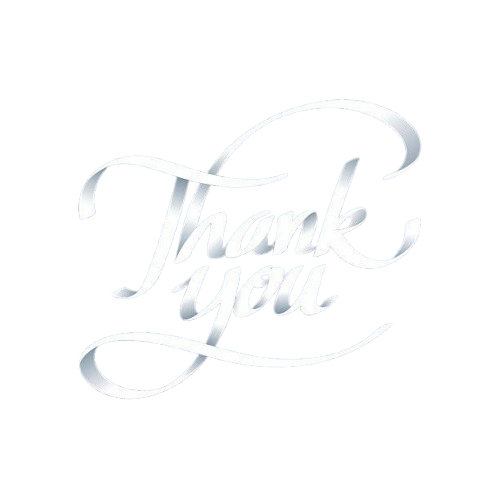

# **COOMING SOON :-**

# **Forecasting Models**

Forecasting models are used to predict future values based on historical time-series data and observed trends.

**Forecasting Models:-**

* ARIMA (Auto-Regressive Integrated
Moving Average)

* SARIMA (Seasonal ARIMA)

* Exponential Smoothing

* Exponential Smoothing (Holt-Winters)

# Model Evaluation and Validation
Model evaluation helps in measuring how well a machine learning model performs.

* Confusion Matrix
* Precision, Recall
* F1-Score
* ROC Curve and AUC
* Cross Validation
* Bias and Variance
* Overfitting and Underfitting
* Regularization
* Resources